# M8.3H — Optical regime stratification

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report** — report ML filters `opt_m8_high_001` only.

Background μa/μs are catalog metadata, never model inputs. Results: `checkpoints/m8/m08_3h_optical_regime/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = True  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    load_m8_catalog_rows,
    load_win3h_results,
    plot_win3h_results,
    run_win3h_optical_regime_study,
    summarize_win3h,
    win3h_results_dir,
    win3_grids_summary,
)

results_dir = win3h_results_dir(ROOT)


## Milestone 8 Step 3H predefined grid

In [5]:
display(win3_grids_summary()['3H_optical_regime'])
run_installed_pytest_test(m8_validation, "test_m8_3h_optical_regime_grid_spans_three_setups")


,name,optical_setup_id,mu_s,mu_a,description
0,low,opt_m8_low_001,0.01,0.003,low attenuation background optics
1,medium,opt_m8_med_001,0.03,0.010,medium attenuation background optics
2,high,opt_m8_high_001,0.10,0.030,high attenuation background optics


M8.3H
Test executed: test_m8_3h_optical_regime_grid_spans_three_setups()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.80s ===============================

Test proves: Milestone 8 Step 3H optical-regime grid spans low / medium / high.


## Train / validation study

In [6]:
from tomography_ml.localization import win3e_control_configs, win3h_optical_regime_grid

rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
summary_df, runs_df = load_win3h_results(ROOT)
expected_runs = len(win3h_optical_regime_grid()) * len(win3e_control_configs()) * int(N_REPEAT)
n_runs = 0 if runs_df is None else int(len(runs_df))
incomplete = n_runs < expected_runs
should_run = RUN_STUDY if RUN_STUDY is not None else incomplete
if should_run:
    # RUN_STUDY=True forces a fresh study; otherwise resume partial CSVs.
    resume = RUN_STUDY is not True
    if RUN_STUDY is True and results_dir.exists():
        for path in results_dir.glob("win3h_optical_regime_*.csv"):
            path.unlink()
            print(f"Removed {display_path(path)} for fresh RUN_STUDY=True")
    summary_df, runs_df, _ = run_win3h_optical_regime_study(
        rows,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
        resume=resume,
    )
else:
    print(f"Loaded existing runs CSV ({n_runs}/{expected_runs}) — set RUN_STUDY=True to retrain.")
display(summary_df)



######## M8 Step 3H optical_regime=low repeat 1/5  seed=0 ########
  fourier_base_mlp rep 1 epoch 001/200  train_loss=29.95767  val_RMSE=3.4544  best=3.4544*  stall=0/40
  fourier_base_mlp rep 1 epoch 002/200  train_loss=8.05732  val_RMSE=2.5482  best=2.5482*  stall=0/40
  fourier_base_mlp rep 1 epoch 003/200  train_loss=4.87040  val_RMSE=2.0152  best=2.0152*  stall=0/40
  fourier_base_mlp rep 1 epoch 004/200  train_loss=3.74197  val_RMSE=1.9766  best=1.9766*  stall=0/40
  fourier_base_mlp rep 1 epoch 005/200  train_loss=3.05482  val_RMSE=1.5799  best=1.5799*  stall=0/40
  fourier_base_mlp rep 1 epoch 006/200  train_loss=3.94515  val_RMSE=2.2072  best=1.5799   stall=1/40
  fourier_base_mlp rep 1 epoch 007/200  train_loss=4.07671  val_RMSE=1.6809  best=1.5799   stall=2/40
  fourier_base_mlp rep 1 epoch 008/200  train_loss=2.73421  val_RMSE=1.5571  best=1.5571*  stall=0/40
  fourier_base_mlp rep 1 epoch 009/200  train_loss=2.29596  val_RMSE=1.5815  best=1.5571   stall=1/40
  fourier_bas

,experiment_id,win,architecture_factor,hypothesis,variant,head_type,downsample,encoder_channels,architecture_config,parameter_count,...,mu_a,train_RMSE_total_mean,train_RMSE_total_std,validation_RMSE_total_mean,validation_RMSE_total_std,best_validation_RMSE_total_mean,best_validation_RMSE_total_std,run_group,n_repeat,seeds
4,win3h__flatten_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,0.010,0.581071,0.036618,0.835037,0.014526,0.835037,0.014526,medium::flatten_base_mlp,5,"0,1,2,3,4"
3,win3h__fourier_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,0.010,0.701046,0.108685,0.919251,0.037901,0.919251,0.037901,medium::fourier_base_mlp,5,"0,1,2,3,4"
1,win3h__flatten_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,0.003,0.769917,0.060457,1.015742,0.035891,1.015742,0.035891,low::flatten_base_mlp,5,"0,1,2,3,4"
0,win3h__fourier_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,0.003,0.858860,0.064081,1.076373,0.045653,1.076373,0.045653,low::fourier_base_mlp,5,"0,1,2,3,4"
7,win3h__flatten_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,0.030,0.762637,0.114142,1.139977,0.092515,1.139977,0.092515,high::flatten_base_mlp,5,"0,1,2,3,4"
6,win3h__fourier_base_mlp,3H,optical_regime,background_optics_nuisance_not_model_input,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,0.030,0.836314,0.100490,1.250882,0.032488,1.250882,0.032488,high::fourier_base_mlp,5,"0,1,2,3,4"
5,win3h__pooled_base_base,3H,optical_regime,background_optics_nuisance_not_model_input,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,0.010,1.433847,0.107497,1.516285,0.084463,1.516285,0.084463,medium::pooled_base_base,5,"0,1,2,3,4"
2,win3h__pooled_base_base,3H,optical_regime,background_optics_nuisance_not_model_input,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,0.003,1.445609,0.080086,1.742540,0.077884,1.742540,0.077884,low::pooled_base_base,5,"0,1,2,3,4"
8,win3h__pooled_base_base,3H,optical_regime,background_optics_nuisance_not_model_input,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,0.030,1.605798,0.057723,1.965727,0.055606,1.965727,0.055606,high::pooled_base_base,5,"0,1,2,3,4"


## Results

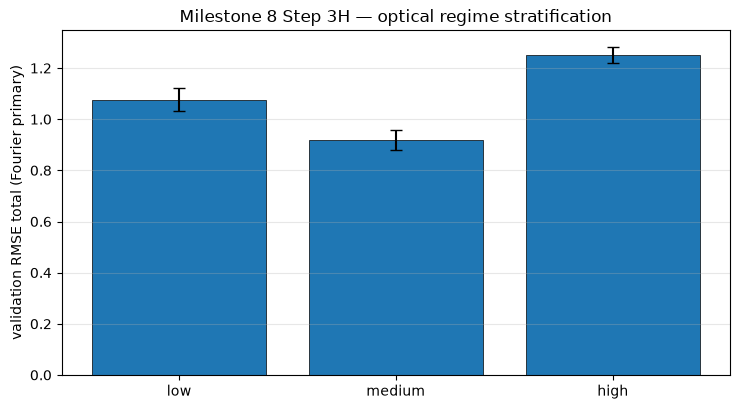

- low: mean val RMSE 1.076.

- medium: mean val RMSE 0.919.

- high: mean val RMSE 1.251.

- Report ML in Final Report filters high regime only; regimes are nuisance stratification.

In [7]:
if summary_df is None or getattr(summary_df, "empty", True):
    display(Markdown(
        "No results yet. Re-run the **Train / validation study** cell "
        "(long studies resume from partial CSVs under "
        "`checkpoints/m8/m08_3h_optical_regime/`)."
    ))
else:
    fig = plot_win3h_results(summary_df)
    plt.show()
    for line in summarize_win3h(summary_df):
        display(Markdown(f"- {line}"))


## Conclusion
The particle localization seams easier in medium scattering gummybears. This can be rationalized by two opposing tendencies: without scattering, the particle does not cast shadows, while strong scattering distrubutes the intensity in the entire gummybear. However, optical properties are part of the physical setup and while they may vary in reality, they are not optimized here.